## Below is the code to recreate Figure 3.

Topic: Showing the atmospheric interpolation between BT-Settl (pre-existing) and Meisner (new) model grids to classify brown dwarf atmospheres.

In [1]:
# Importing necessary packages.
import matplotlib.pyplot as plt
from astropy.io import fits

In [2]:
# Define path to atmospheric model files
cdbs_path = '/System/Volumes/Data/mnt/g/lu/models/cdbs'
logg = 4.5

# 1000 K, plot 1
merged_file_1000 = f'{cdbs_path}/grid/merged_BTSettl_meisner/merged_T1000_g{logg}_Z0.0.fits'
bt_file_1000 = f'{cdbs_path}/grid/BTSettl_rebin/btp00/lte010-{logg}-0.0a+0.0.BT-Settl.spec.fits'
meisner_file_1000 = f'{cdbs_path}/grid/Meisner2023_rebin/mp00/spec_jwst_t1000_g{logg}_p0_kg_g1.25.fits'

# 1100 K, plot 2
merged_file_1100 = f'{cdbs_path}/grid/merged_BTSettl_meisner/merged_T1100_g{logg}_Z0.0.fits'
bt_file_1100 = f'{cdbs_path}/grid/BTSettl_rebin/btp00/lte011-{logg}-0.0a+0.0.BT-Settl.spec.fits'
meisner_file_1100 = f'{cdbs_path}/grid/Meisner2023_rebin/mp00/spec_jwst_t1100_g{logg}_p0_kg_g1.25.fits'

# 1200 K, plot 3
merged_file_1200 = f'{cdbs_path}/grid/merged_BTSettl_meisner/merged_T1200_g{logg}_Z0.0.fits'
bt_file_1200 = f'{cdbs_path}/grid/BTSettl_rebin/btp00/lte012-{logg}-0.0a+0.0.BT-Settl.spec.fits'
meisner_file_1200 = f'{cdbs_path}/grid/Meisner2023_rebin/mp00/spec_jwst_t1200_g{logg}_p0_kg_g1.25.fits'

with fits.open(merged_file_1000) as h:
    wave = h[1].data['Wavelength']
    merged_flux_1000 = h[1].data['Flux']

with fits.open(bt_file_1000) as h:
    bt_flux_1000 = h[1].data['Flux']

with fits.open(meisner_file_1000) as h:
    meis_flux_1000 = h[1].data['Flux']

with fits.open(merged_file_1100) as h:
    merged_flux_1100 = h[1].data['Flux']

with fits.open(bt_file_1100) as h:
    bt_flux_1100 = h[1].data['Flux']

with fits.open(meisner_file_1100) as h:
    meis_flux_1100 = h[1].data['Flux']

with fits.open(merged_file_1200) as h:
    merged_flux_1200 = h[1].data['Flux']

with fits.open(bt_file_1200) as h:
    bt_flux_1200 = h[1].data['Flux']

with fits.open(meisner_file_1200) as h:
    meis_flux_1200 = h[1].data['Flux']

wave_scaled = wave/1e4

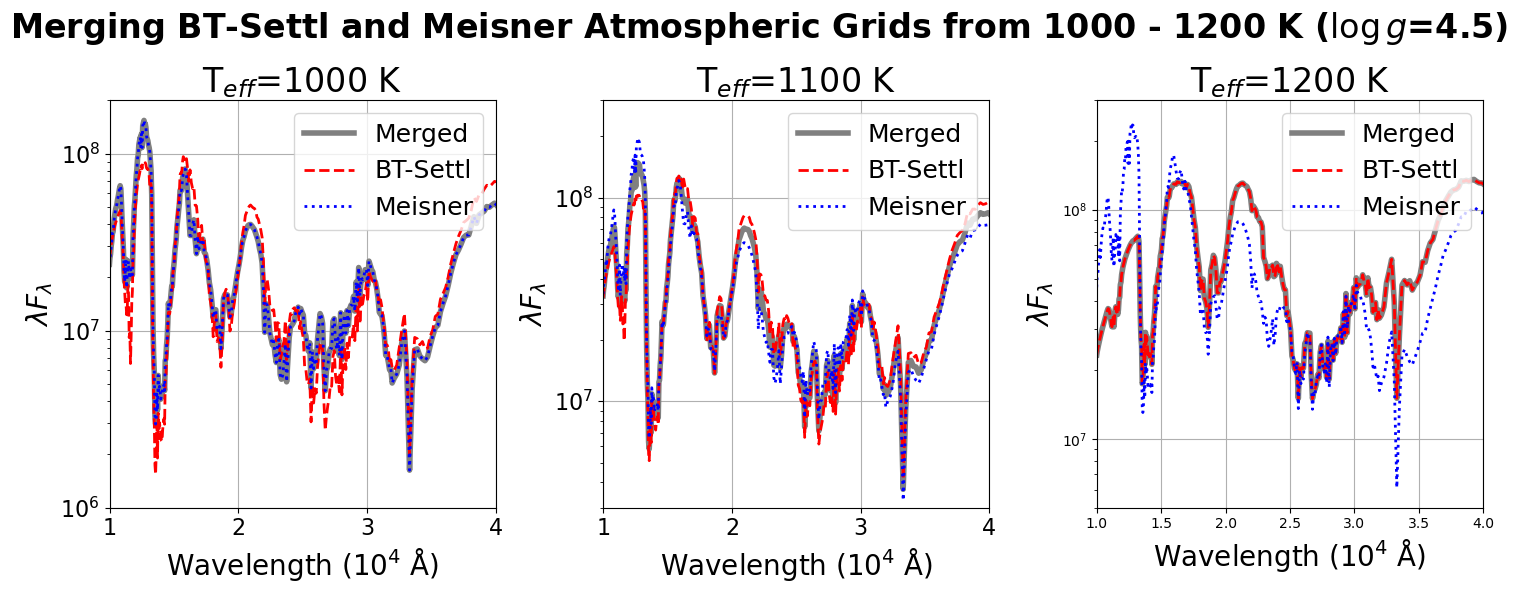

In [3]:
# Plot the figure
fig, axs = plt.subplots(1, 3, figsize=(15,6))

axs[0].semilogy(wave_scaled, wave * merged_flux_1000, label='Merged', lw=4, color='gray')
axs[0].semilogy(wave_scaled, wave * bt_flux_1000, label='BT-Settl', lw=2, color='red', linestyle='--')
axs[0].semilogy(wave_scaled, wave * meis_flux_1000, label='Meisner', lw=2, color='blue', linestyle=':')

axs[0].set_xlabel('Wavelength ($10^4$ Å)', fontsize=20)
axs[0].set_ylabel(r'$\lambda F_\lambda$', fontsize=20)
axs[0].set_xlim(1, 4)
axs[0].set_ylim(1e6, 2e8)
axs[0].tick_params(axis='both', labelsize=16)
axs[0].legend(loc='upper right', fontsize=18)
axs[0].set_title(r'T$_{eff}$=1000 K', fontsize=24)
axs[0].grid()


axs[1].semilogy(wave_scaled, wave * merged_flux_1100, label='Merged', lw=4, color='gray')
axs[1].semilogy(wave_scaled, wave * bt_flux_1100, label='BT-Settl', lw=2, color='red', linestyle='--')
axs[1].semilogy(wave_scaled, wave * meis_flux_1100, label='Meisner', lw=2, color='blue', linestyle=':')

axs[1].set_xlabel('Wavelength ($10^4$ Å)', fontsize=20)
axs[1].set_ylabel(r'$\lambda F_\lambda$', fontsize=20)
axs[1].set_xlim(1, 4)
axs[1].set_ylim(3e6, 3e8)
axs[1].tick_params(axis='both', labelsize=16)
axs[1].legend(loc='upper right', fontsize=18)
axs[1].set_title(r'T$_{eff}$=1100 K', fontsize=24)
axs[1].grid()


axs[2].semilogy(wave_scaled, wave * merged_flux_1200, label='Merged', lw=4, color='gray')
axs[2].semilogy(wave_scaled, wave * bt_flux_1200, label='BT-Settl', lw=2, color='red', linestyle='--')
axs[2].semilogy(wave_scaled, wave * meis_flux_1200, label='Meisner', lw=2, color='blue', linestyle=':')

axs[2].set_xlabel('Wavelength ($10^4$ Å)', fontsize=20)
axs[2].set_ylabel(r'$\lambda F_\lambda$', fontsize=20)
axs[2].set_xlim(1, 4)
axs[2].set_ylim(5e6, 3e8)
axs[2].legend(loc='upper right', fontsize=18)
axs[2].set_title(r'T$_{eff}$=1200 K', fontsize=24)
axs[2].grid()

plt.suptitle('Merging BT-Settl and Meisner Atmospheric Grids from 1000 - 1200 K ($\log g$=4.5)',
            fontsize=24, fontweight='bold')
plt.tight_layout()
plt.savefig('atmo_merge.png')
plt.show()